In [1]:
import os
import shutil
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix


Separate the .wav data into two sub folder with label 1 or 0

In [ ]:
# Set your source directory where the .wav files are
source_dir = "/Users/silent360/Meng_Study/GMU/DAEN690/Data/QiandaoEar22"

# Set destination directories
label_0_dir = os.path.join(source_dir, "label_0")
label_1_dir = os.path.join(source_dir, "label_1")

# Create destination folders if they don't exist
os.makedirs(label_0_dir, exist_ok=True)
os.makedirs(label_1_dir, exist_ok=True)

# Loop through all .wav files
for filename in os.listdir(source_dir):
    if filename.endswith(".wav"):
        src_path = os.path.join(source_dir, filename)
        if "label__1" in filename:
            dest_path = os.path.join(label_1_dir, filename)
        elif "label__0" in filename:
            dest_path = os.path.join(label_0_dir, filename)
        else:
            continue  # skip files without proper label tag
        shutil.move(src_path, dest_path)  # use shutil.copy() if you don't want to move

print("Files have been successfully separated into 'label_0' and 'label_1' folders.")

In [2]:
# Parameters
SAMPLE_RATE = 22050
N_FFT = 1024
HOP_LENGTH = 512
DURATION = 3  # in seconds
N_FRAMES = int((SAMPLE_RATE * DURATION) / HOP_LENGTH) + 1
N_BINS = N_FFT // 2 + 1  # Frequency bins from STFT
INPUT_SHAPE = (N_BINS, N_FRAMES, 1)

# === Audio Preprocessing ===
def bandpass_filter(data, sr, lowcut, highcut):
    from scipy.signal import butter, lfilter
    nyq = 0.5 * sr
    b, a = butter(4, [lowcut / nyq, highcut / nyq], btype='band')
    return lfilter(b, a, data)

def load_and_extract_stft(file_path):
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
    y = bandpass_filter(y, sr, lowcut=100, highcut=4000)
    
    # STFT and convert to log scale
    stft = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
    spectrogram = np.abs(stft)
    log_stft = librosa.amplitude_to_db(spectrogram, ref=np.max)

    # Pad or crop to fixed size
    if log_stft.shape[1] < N_FRAMES:
        pad_width = N_FRAMES - log_stft.shape[1]
        log_stft = np.pad(log_stft, ((0, 0), (0, pad_width)), mode='constant')
    elif log_stft.shape[1] > N_FRAMES:
        log_stft = log_stft[:, :N_FRAMES]

    return log_stft

def load_data(folder_dict):
    X, y = [], []
    label_map = {name: i for i, name in enumerate(folder_dict)}
    for label, path in folder_dict.items():
        for file in os.listdir(path):
            if file.endswith(".wav"):
                try:
                    stft_feature = load_and_extract_stft(os.path.join(path, file))
                    if stft_feature.shape == (N_BINS, N_FRAMES):
                        X.append(stft_feature)
                        y.append(label_map[label])
                except Exception as e:
                    print(f"Error processing {file}: {e}")
    X = np.array(X)[..., np.newaxis]  # Add channel dimension
    y = to_categorical(y, num_classes=len(label_map))
    return X, y

def build_cnn(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [3]:
folder_paths = {
    "1": "/Users/silent360/Meng_Study/GMU/DAEN690/Data/QiandaoEar22/label_1",
    "0": "/Users/silent360/Meng_Study/GMU/DAEN690/Data/QiandaoEar22/label_0"
    # Add more folders if needed
}

In [4]:
X, y = load_data(folder_paths)

/var/folders/rs/hbhbdcxx3j94md71rsn1l5lr0000gn/T/ipykernel_4338/1420537978.py:18: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
/Users/silent360/anaconda3/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error processing 20220628095213_M_TheEarl_N_M&TheKnight_N_M&QianDao_M_M&QianDao_M_M_2_label__1__27_1.wav: 
Error processing 20220628094211_M_Cargo_N_M&TheEarl_N_M&TheKnight_N_M&QianDao_N_M_2_label__1__25.wav: 
Error processing 20220626170345_M_QianDao_F_W&SpeedBoat_M_M&SpeedBoat_F_W&SpeedBoat_F_W&SpeedBoat_F_W_0_label__1__8_1.wav: 
Error processing 20220628095713_M_TheEarl_N_M&TheKnight_N_M&SpeedBoat_F_W&SpeedBoat_F_W_1_label__1__8.wav: 
Error processing 20220626111239_M_SpeedBoat_F_W&SpeedBoat_F_W_2_label__1__22_1.wav: 
Error processing 20220626161837_M_SpeedBoat_M_M&SpeedBoat_M_M_2_label__1__3_1.wav: 
Error processing 20220626112743_M_GreenCity_M_M&SpeedBoat_M_M_0_label__1__23.wav: 
Error processing 20220628093209_M_GreenCity_N_S&SpeedBoat_N_S_1_label__1__10.wav: 
Error processing 20220628100715_M_QianDao_N_S&TheEarl_M_M&QianDao_M_M&QianDao_M_M_4_label__1__9.wav: 
Error processing 20220628155321_M_QianDao_N_S&QianDao_N_S&SpeedBoat_M_M&SpeedBoat_M_M&SpeedBoat_F_W_3_label__1__15_1.wav:

In [19]:
np.save("features.npy", X)
np.save("labels.npy", y)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
model = build_cnn(INPUT_SHAPE, num_classes=y.shape[1])
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
model.fit(X_train, y_train, validation_split=0.2, epochs=5, batch_size=16, callbacks=[early_stop])

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

/Users/silent360/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
776/776 ━━━━━━━━━━━━━━━━━━━━ 469s 602ms/step - accuracy: 0.8431 - loss: 6.6195 - val_accuracy: 0.8497 - val_loss: 0.2714
Epoch 2/5
776/776 ━━━━━━━━━━━━━━━━━━━━ 418s 538ms/step - accuracy: 0.8689 - loss: 0.3167 - val_accuracy: 0.8507 - val_loss: 0.2839
Epoch 3/5
776/776 ━━━━━━━━━━━━━━━━━━━━ 524s 675ms/step - accuracy: 0.8640 - loss: 0.2598 - val_accuracy: 0.8497 - val_loss: 0.2714
Epoch 4/5
776/776 ━━━━━━━━━━━━━━━━━━━━ 444s 572ms/step - accuracy: 0.8662 - loss: 0.2539 - val_accuracy: 0.8491 - val_loss: 20.9441
Epoch 5/5
776/776 ━━━━━━━━━━━━━━━━━━━━ 458s 590ms/step - accuracy: 0.8691 - loss: 0.4758 - val_accuracy: 0.8491 - val_loss: 0.3949
122/122 ━━━━━━━━━━━━━━━━━━━━ 18s 144ms/step - accuracy: 0.8650 - loss: 0.3031
Test accuracy: 0.8633


In [9]:
model.save("cnn_stft_model.keras")  

In [2]:
X = np.load("features.npy")
y = np.load("labels.npy")

In [4]:
model = load_model("cnn_stft_model.keras")

/Users/silent360/anaconda3/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [5]:
# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


122/122 ━━━━━━━━━━━━━━━━━━━━ 18s 145ms/step - accuracy: 0.8650 - loss: 0.3031
Test Loss: 0.2873
Test Accuracy: 0.8633


122/122 ━━━━━━━━━━━━━━━━━━━━ 17s 140ms/step
              precision    recall  f1-score   support

           0       0.86      1.00      0.93      3346
           1       0.00      0.00      0.00       530

    accuracy                           0.86      3876
   macro avg       0.43      0.50      0.46      3876
weighted avg       0.75      0.86      0.80      3876



/Users/silent360/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/silent360/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/silent360/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


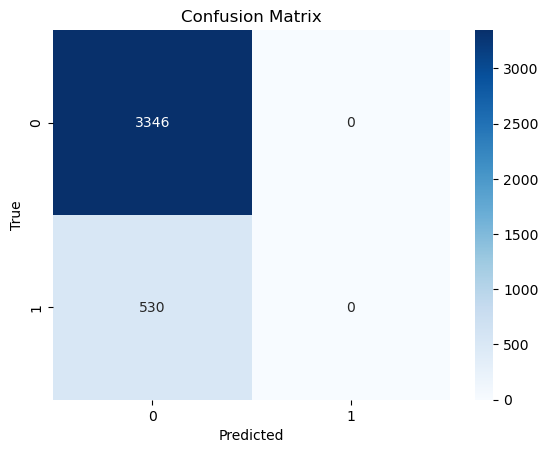

In [6]:
# Predict class probabilities
y_pred_probs = model.predict(X_test)

# Convert to class labels
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Print detailed classification report
print(classification_report(y_true, y_pred))

# Optional: Confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
